INICIO DE ANÁLISIS


Procesando CSV: ANE7-ALL

Procesando CSV: ANE9-ALL

Procesando CSV: ANE10-ALL

RESUMEN INICIAL DE CSVs
ANE7-ALL:
   - Columnas totales: 58
   - Columnas numéricas: 48
ANE9-ALL:
   - Columnas totales: 58
   - Columnas numéricas: 48
ANE10-ALL:
   - Columnas totales: 58
   - Columnas numéricas: 48

ANÁLISIS DE CONSISTENCIA: Columnas >50% NaN

[CONSISTENTES EN TODOS] (5):
['dpi_mhz', 'h264_mhz', 'pixel_mhz', 'pwm_mhz', 'vec_mhz']

[INCONSISTENTES] (0):
[]

[DETALLE POR CSV]
ANE7-ALL: ['dpi_mhz', 'h264_mhz', 'pixel_mhz', 'pwm_mhz', 'vec_mhz']
ANE9-ALL: ['dpi_mhz', 'h264_mhz', 'pixel_mhz', 'pwm_mhz', 'vec_mhz']
ANE10-ALL: ['dpi_mhz', 'h264_mhz', 'pixel_mhz', 'pwm_mhz', 'vec_mhz']

ANÁLISIS DE CONSISTENCIA: Columnas sin variabilidad

[CONSISTENTES EN TODOS] (6):
['emmc_mhz', 'hdmi_mhz', 'readmr_4', 'readmr_5', 'readmr_6', 'readmr_8']

[INCONSISTENTES] (3):
['BATT_V', 'sdram_c_volt', 'sdram_i_volt']

[DETALLE POR CSV]
ANE7-ALL: ['emmc_mhz', 'hdmi_mhz', 'readmr_4', 'readmr_

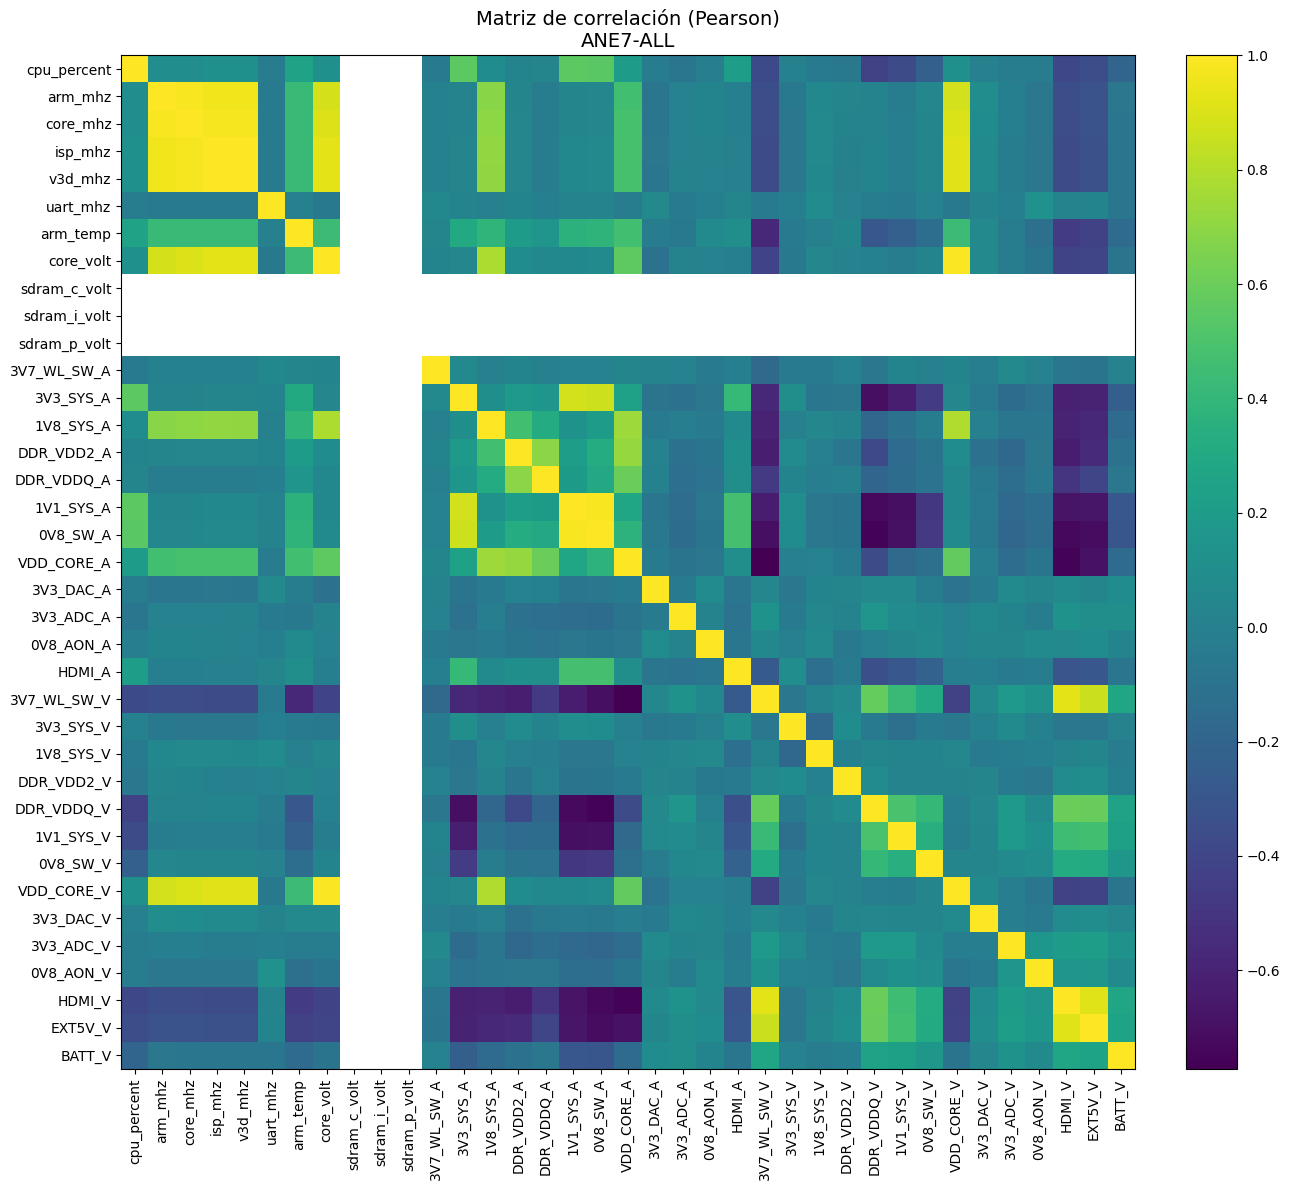


[INFO] ANE9-ALL -> columnas finales: 37


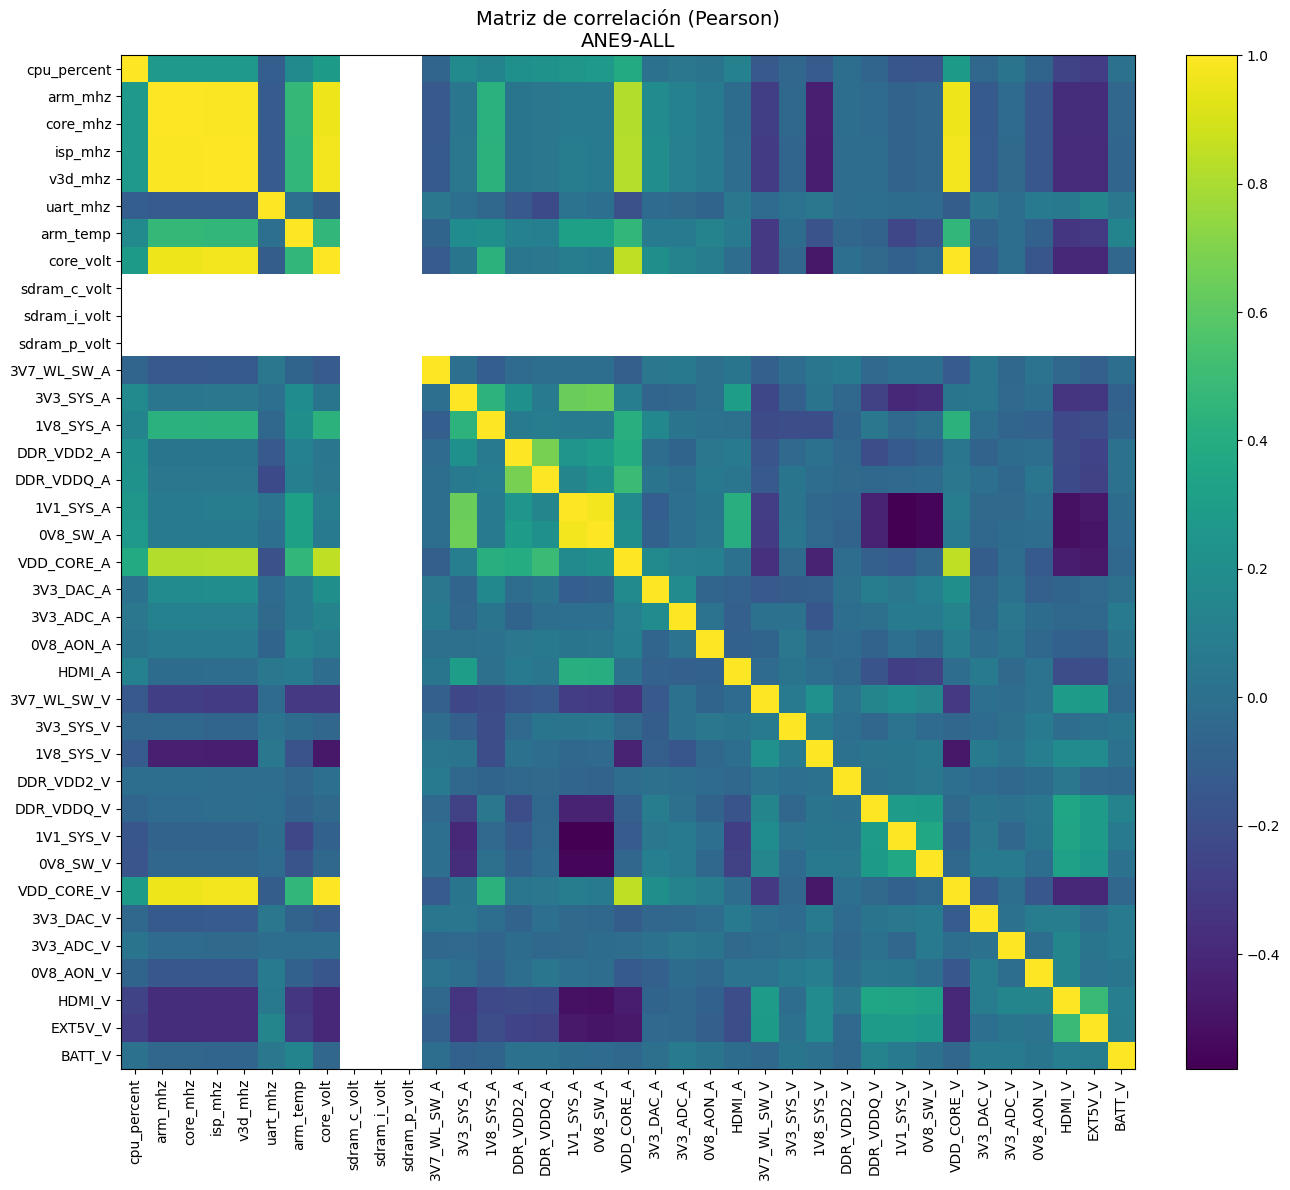


[INFO] ANE10-ALL -> columnas finales: 37


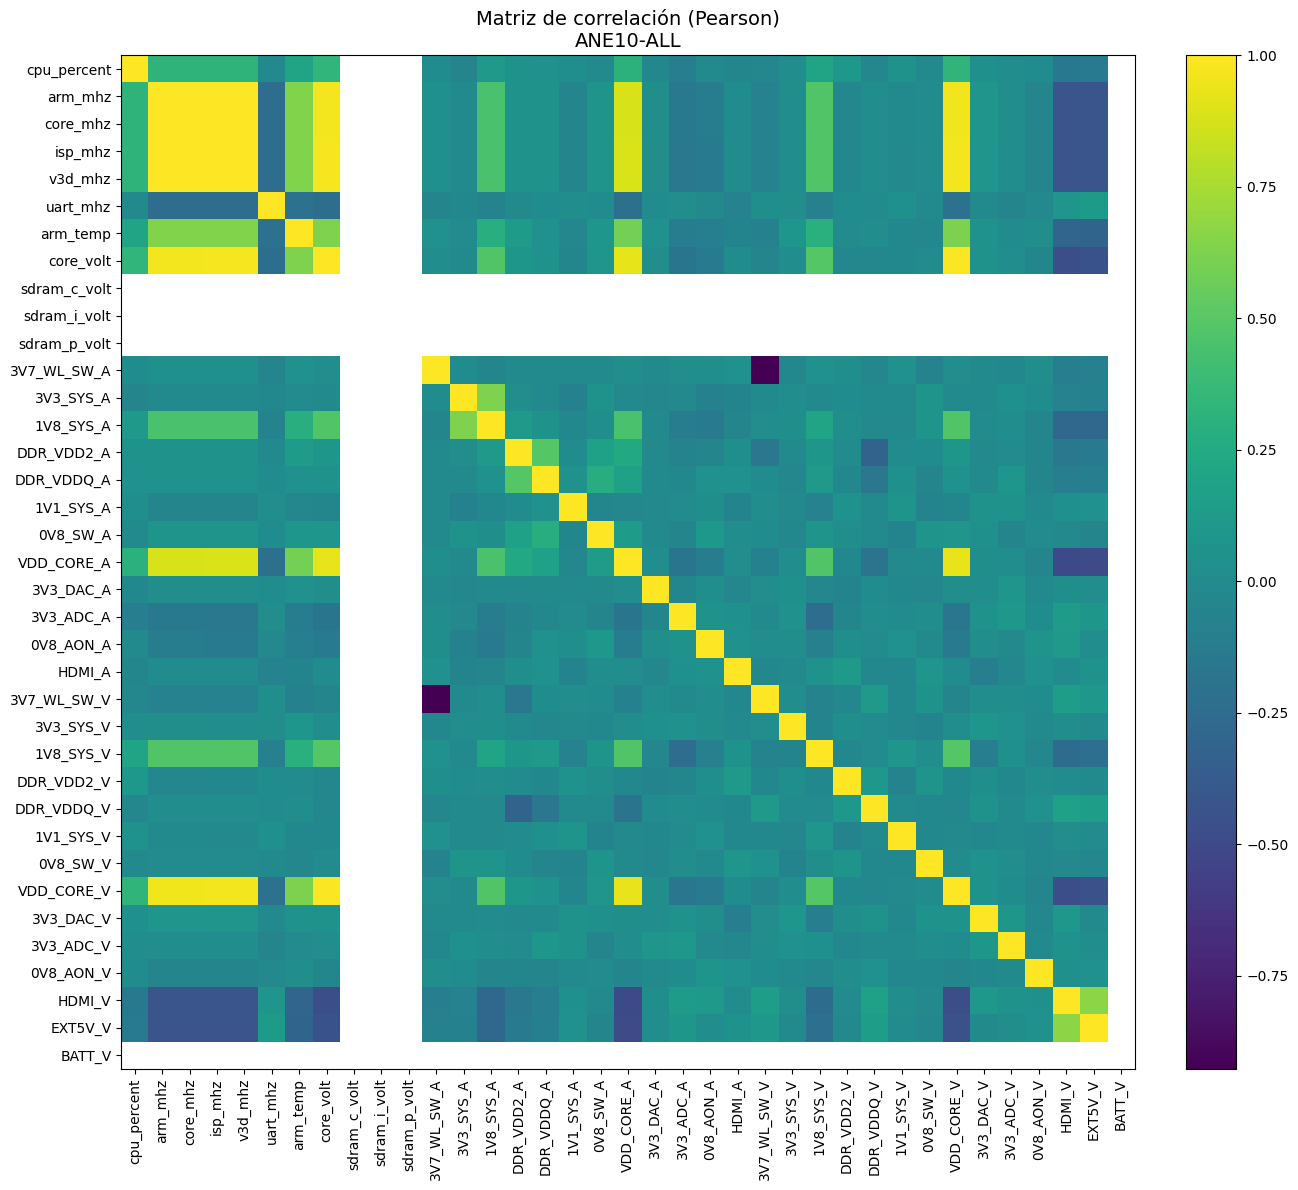


FIN DEL ANÁLISIS
Archivo de log generado: analysis_log_20260413_205628.txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# --------------------------------------------
# CONFIG
# --------------------------------------------
CSV_PATHS = [
    "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/ANE7-ALL/ALL_PERIPH_MID_PETITION.csv",
    "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/ANE9-ALL/ALL_PERIPH_MID_PETITION.csv",
    "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/ANE10-ALL/ALL_PERIPH_MID_PETITION.csv"
]

LOW_VAR_THRESHOLD = 1e-6

# archivo de log
LOG_FILE = f"analysis_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

# --------------------------------------------
# LOGGER
# --------------------------------------------
def log(msg, to_console=True):
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(msg + "\n")
    if to_console:
        print(msg)

# limpiar archivo al inicio
open(LOG_FILE, "w").close()

log("INICIO DE ANÁLISIS\n")

# --------------------------------------------
# FUNCIONES
# --------------------------------------------
def analyze_csv(path):
    df = pd.read_csv(path)

    total_cols = len(df.columns)

    df_numeric = df.select_dtypes(include=[np.number])
    numeric_cols = len(df_numeric.columns)

    nan_ratio = df_numeric.isna().mean()
    cols_high_nan = set(nan_ratio[nan_ratio > 0.5].index)

    std = df_numeric.std()
    cols_constant = set(std[std == 0].index)

    cols_low_var = set(std[(std > 0) & (std < LOW_VAR_THRESHOLD)].index)

    return {
        "df": df_numeric,
        "cols_high_nan": cols_high_nan,
        "cols_constant": cols_constant,
        "cols_low_var": cols_low_var,
        "columns": set(df_numeric.columns),
        "total_cols": total_cols,
        "numeric_cols": numeric_cols
    }

def print_consistency(name, dict_sets):
    log("\n" + "="*80)
    log(f"ANÁLISIS DE CONSISTENCIA: {name}")
    log("="*80)

    all_sets = list(dict_sets.values())

    common = set.intersection(*all_sets)
    union = set.union(*all_sets)

    log(f"\n[CONSISTENTES EN TODOS] ({len(common)}):")
    log(str(sorted(common)))

    log(f"\n[INCONSISTENTES] ({len(union - common)}):")
    log(str(sorted(union - common)))

    log("\n[DETALLE POR CSV]")
    for k, v in dict_sets.items():
        log(f"{k}: {sorted(v)}")

    return common


# --------------------------------------------
# 1. ANALIZAR TODOS LOS CSV
# --------------------------------------------
results = {}

for path in CSV_PATHS:
    name = os.path.basename(os.path.dirname(path))
    log(f"\nProcesando CSV: {name}")
    results[name] = analyze_csv(path)

log("\n" + "="*80)
log("RESUMEN INICIAL DE CSVs")
log("="*80)

for name, res in results.items():
    log(f"{name}:")
    log(f"   - Columnas totales: {res['total_cols']}")
    log(f"   - Columnas numéricas: {res['numeric_cols']}")

# --------------------------------------------
# 2. CONSISTENCIA DE COLUMNAS
# --------------------------------------------
cols_high_nan_dict = {k: v["cols_high_nan"] for k, v in results.items()}
cols_constant_dict = {k: v["cols_constant"] for k, v in results.items()}
cols_low_var_dict = {k: v["cols_low_var"] for k, v in results.items()}

common_high_nan = print_consistency("Columnas >50% NaN", cols_high_nan_dict)
common_constant = print_consistency("Columnas sin variabilidad", cols_constant_dict)

# SOLO ANÁLISIS (NO eliminar)
print_consistency("Columnas con muy baja variabilidad (NO se eliminan)", cols_low_var_dict)

# --------------------------------------------
# 3. COLUMNAS A ELIMINAR
# --------------------------------------------
cols_to_remove = common_high_nan.union(common_constant)

log("\n" + "="*80)
log("[COLUMNAS ELIMINADAS FINALMENTE]")
log("="*80)
log(str(sorted(cols_to_remove)))

# --------------------------------------------
# 4. PROCESAR Y PLOT POR CSV
# --------------------------------------------
for name, res in results.items():

    df = res["df"].copy()

    df = df.drop(columns=[c for c in cols_to_remove if c in df.columns], errors='ignore')

    log(f"\n[INFO] {name} -> columnas finales: {len(df.columns)}")

    # correlación
    corr_matrix = df.corr(method="pearson")

    # plot
    plt.figure(figsize=(14, 12))
    im = plt.imshow(corr_matrix, interpolation='nearest')

    plt.title(f"Matriz de correlación (Pearson)\n{name}", fontsize=14)

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()

    plt.show()

log("\nFIN DEL ANÁLISIS")
log(f"Archivo de log generado: {LOG_FILE}")

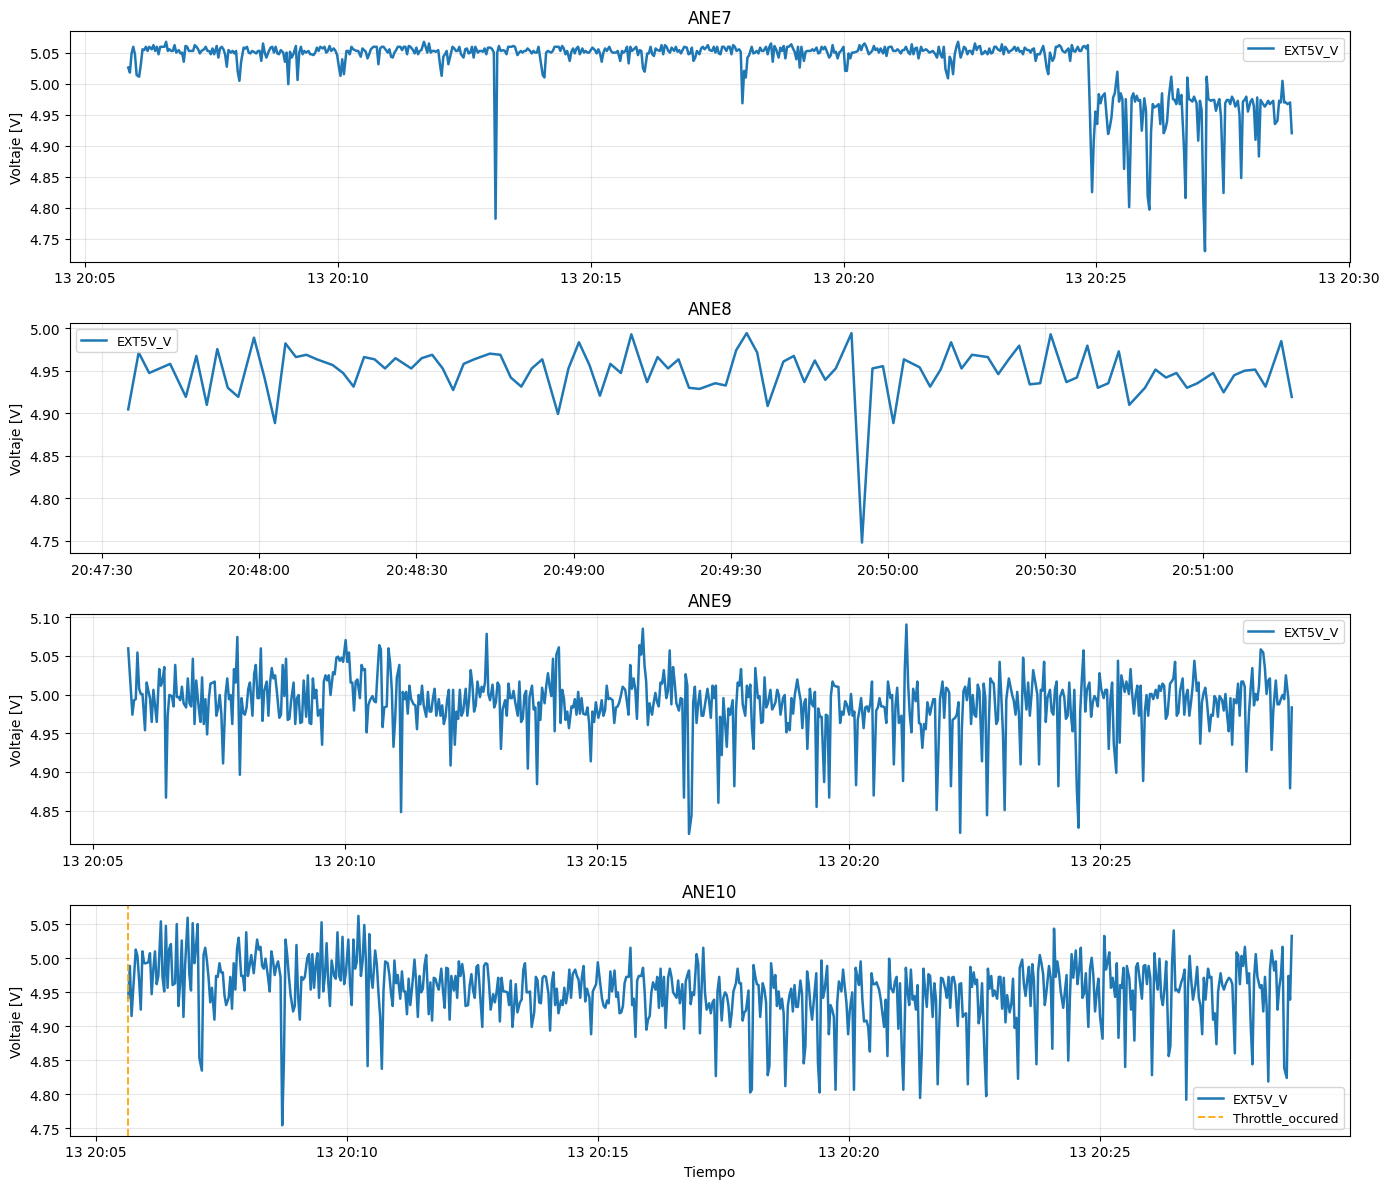

In [ ]:

# ============================================================
# PATHS
# ============================================================
FILES = {
    "ANE7": "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/experiment/rpi5_telemetry_ANE7.csv",
    "ANE8": "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/experiment/rpi5_telemetry_ANE8.csv",
    "ANE9": "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/experiment/rpi5_telemetry_ANE9.csv",
    "ANE10": "/home/ogutierreze/GPDS_Proyects/dsp_gcpds/data_sensors/experiment/rpi5_telemetry_ANE10.csv",
}

# ============================================================
# FLAGS
# ============================================================
flag_cols = ["UV", "CurThrottle", "Throttle_occured"]

flag_colors = {
    "UV": "red",
    "CurThrottle": "purple",
    "Throttle_occured": "orange",
}

# ============================================================
# FUNCIONES
# ============================================================
def normalize_yes_no(series):
    """
    Convierte 'Yes'/'No' a 1/0 de forma robusta
    """
    return series.astype(str).str.strip().str.lower().map({
        "yes": 1,
        "no": 0
    }).fillna(0).astype(int)

def rising_edges(series):
    s = series.fillna(0).astype(int)
    return s.diff().fillna(s.iloc[0]).gt(0)

# ============================================================
# GRAFICA
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, (name, path) in zip(axes, FILES.items()):
    
    df = pd.read_csv(path)

    # timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # voltaje
    df["EXT5V_V"] = pd.to_numeric(df["EXT5V_V"], errors="coerce")

    # flags (Yes/No → 1/0)
    for col in flag_cols:
        if col in df.columns:
            df[col] = normalize_yes_no(df[col])
        else:
            df[col] = 0

    # plot principal
    ax.plot(df["timestamp"], df["EXT5V_V"], linewidth=1.8, label="EXT5V_V")

    # eventos de flags
    for col in flag_cols:
        mask = rising_edges(df[col])
        times = df.loc[mask, "timestamp"]

        for i, t in enumerate(times):
            ax.axvline(
                x=t,
                linestyle="--",
                linewidth=1.4,
                alpha=0.9,
                color=flag_colors[col],
                label=col if i == 0 else None
            )

    ax.set_title(name)
    ax.set_ylabel("Voltaje [V]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

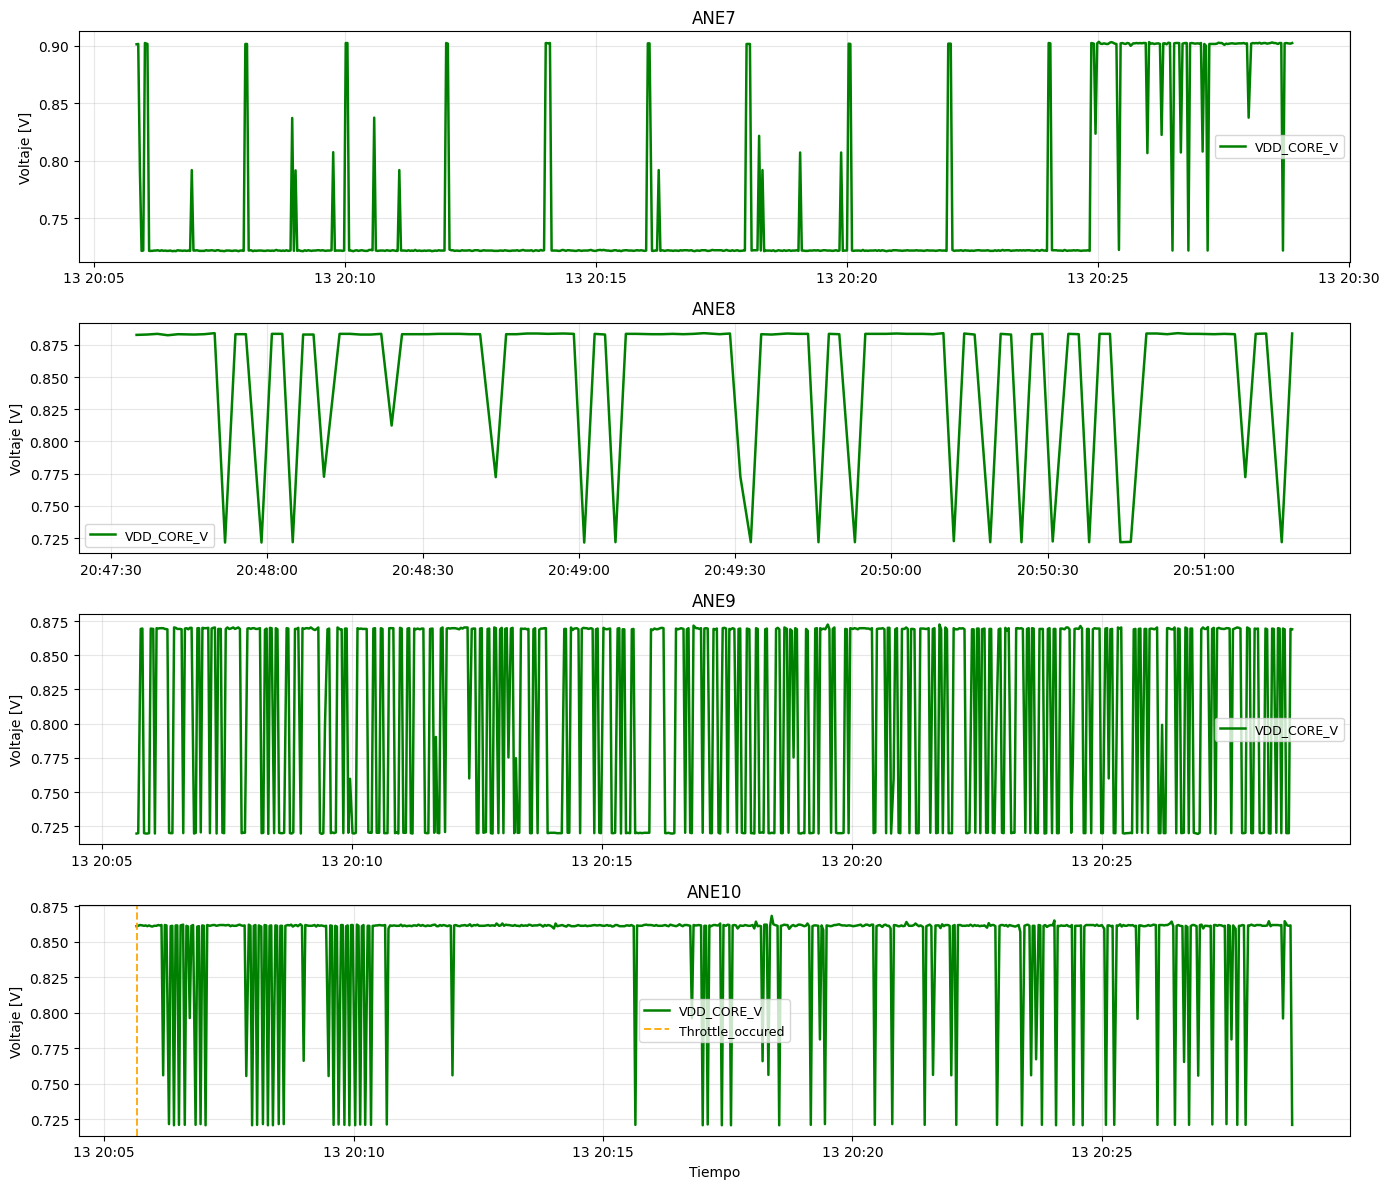

In [ ]:

# ============================================================
# VARIABLES A GRAFICAR
# ============================================================
volt_cols = [ "VDD_CORE_V"]

volt_colors = {
    "VDD_CORE_V": "green",
}

# ============================================================
# FLAGS
# ============================================================
flag_cols = ["UV", "CurThrottle", "Throttle_occured"]

flag_colors = {
    "UV": "red",
    "CurThrottle": "purple",
    "Throttle_occured": "orange",
}

# ============================================================
# FUNCIONES
# ============================================================
def normalize_yes_no(series):
    return series.astype(str).str.strip().str.lower().map({
        "yes": 1,
        "no": 0
    }).fillna(0).astype(int)

def rising_edges(series):
    s = series.fillna(0).astype(int)
    return s.diff().fillna(s.iloc[0]).gt(0)

# ============================================================
# GRAFICA
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, (name, path) in zip(axes, FILES.items()):
    
    df = pd.read_csv(path)

    # timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # voltajes
    for col in volt_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            df[col] = None

    # flags
    for col in flag_cols:
        if col in df.columns:
            df[col] = normalize_yes_no(df[col])
        else:
            df[col] = 0

    # =========================
    # plot voltajes
    # =========================
    for col in volt_cols:
        if col in df.columns and df[col].notna().any():
            ax.plot(
                df["timestamp"],
                df[col],
                label=col,
                color=volt_colors[col],
                linewidth=1.8
            )

    # =========================
    # plot flags
    # =========================
    for col in flag_cols:
        mask = rising_edges(df[col])
        times = df.loc[mask, "timestamp"]

        for i, t in enumerate(times):
            ax.axvline(
                x=t,
                linestyle="--",
                linewidth=1.4,
                alpha=0.9,
                color=flag_colors[col],
                label=col if i == 0 else None
            )

    ax.set_title(name)
    ax.set_ylabel("Voltaje [V]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

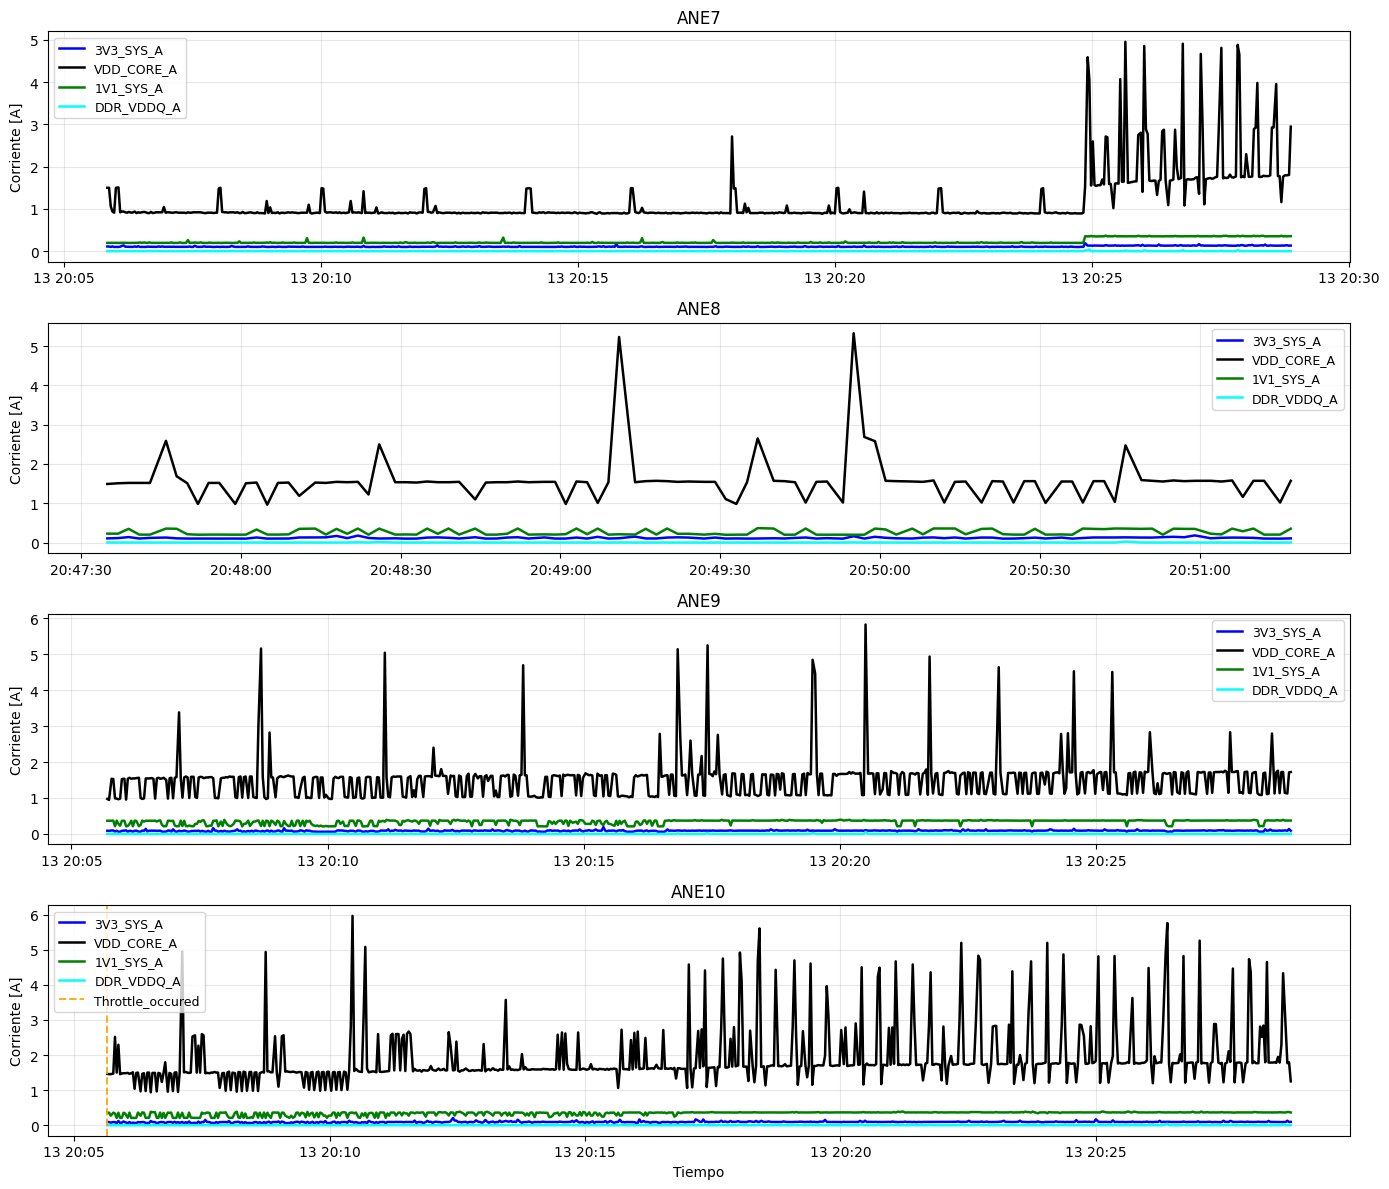

In [ ]:

# ============================================================
# VARIABLES (corrientes)
# ============================================================
current_cols = ["3V3_SYS_A", "VDD_CORE_A", "1V1_SYS_A", "DDR_VDDQ_A"]

current_colors = {
    "3V3_SYS_A": "blue",
    "VDD_CORE_A": "black",
    "1V1_SYS_A": "green",
    "DDR_VDDQ_A": "cyan",
}

# ============================================================
# FLAGS
# ============================================================
flag_cols = ["UV", "CurThrottle", "Throttle_occured"]

flag_colors = {
    "UV": "red",
    "CurThrottle": "purple",
    "Throttle_occured": "orange",
}

# ============================================================
# FUNCIONES
# ============================================================
def normalize_yes_no(series):
    return series.astype(str).str.strip().str.lower().map({
        "yes": 1,
        "no": 0
    }).fillna(0).astype(int)

def rising_edges(series):
    s = series.fillna(0).astype(int)
    return s.diff().fillna(s.iloc[0]).gt(0)

# ============================================================
# GRAFICA
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, (name, path) in zip(axes, FILES.items()):
    
    df = pd.read_csv(path)

    # timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # corrientes
    for col in current_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            df[col] = None

    # flags
    for col in flag_cols:
        if col in df.columns:
            df[col] = normalize_yes_no(df[col])
        else:
            df[col] = 0

    # =========================
    # plot corrientes
    # =========================
    for col in current_cols:
        if col in df.columns and df[col].notna().any():
            ax.plot(
                df["timestamp"],
                df[col],
                label=col,
                color=current_colors[col],
                linewidth=1.8
            )

    # =========================
    # plot flags
    # =========================
    for col in flag_cols:
        mask = rising_edges(df[col])
        times = df.loc[mask, "timestamp"]

        for i, t in enumerate(times):
            ax.axvline(
                x=t,
                linestyle="--",
                linewidth=1.4,
                alpha=0.9,
                color=flag_colors[col],
                label=col if i == 0 else None
            )

    ax.set_title(name)
    ax.set_ylabel("Corriente [A]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()